Importación de librerías
Para comenzar con la revisión de los datos, se procede a importar las librerías especializadas.

In [ ]:
#Iniciamos importando las librerias 
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt 
from pathlib import Path  
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
RANDOM_STATE = 42
print(f"Librerias importadas OK ✅")

Librerias importadas OK ✅


Carga del conjunto de datos
Una vez preparado el entorno de trabajo, hacemos la carga de la base de datos correspondiente a la cartera de clientes del Banco Sabadell. El conjunto de datos representa el comportamiento financiero de aproximadamente 10.000 de clientes

In [ ]:
#Carga del dataset de Sabadell en Python, se agrego la libreria
##from pathlib import Path para que suba sin necesidad de colocar el directorio
# en el df_datasabadell se demora uno aproximadamente 4 seg porque es de 10000 registros la BD
input_dir = Path.cwd() / "input"
xlsx_files = []
if input_dir.exists():
    xlsx_files = sorted(input_dir.glob("*.xlsx"))
else:
    xlsx_files = sorted(Path.cwd().glob("*.xlsx"))

if not xlsx_files:
    raise FileNotFoundError(
        f"No se encontró ningún archivo .xlsx en {input_dir} ni en el directorio actual."
    )

excel_path = xlsx_files[0]
df_datasabadell = pd.read_excel(excel_path, engine="openpyxl")
print(f"Listo✅! Excel cargado desde: {excel_path}")
print(f"output_dir será: {Path.cwd() / 'output'}")


Listo✅! Excel cargado desde: c:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\Entrega 1 -TFM Ethos\BD_Sabadell.xlsx
output_dir será: c:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\Entrega 1 -TFM Ethos\output


El siguiente análisis es para revisar medidas estadísticas descriptivas para así resumir miles de registros en indicadores fácilmente interpretables.

In [286]:
# Estadística descriptiva de las variables clave de perfil / consumo
vars_clave = ['antig','edad','totalpasta','renta_final','gastos_tot','nivren',
              'margecomercialut','credit','revolving','tothipo','nominaimp','rdom','tpv']
df_datasabadell[vars_clave].describe().T

,count,mean,std,min,25%,50%,75%,max
antig,10000.0,218.333500,795.911927,1.00,47.000000,121.000,233.000000,9999.00
edad,10000.0,49.354400,20.248531,0.00,36.000000,49.000,64.000000,116.00
totalpasta,10000.0,23847.890669,86505.052000,0.00,287.467500,2123.225,17078.425000,4798534.49
renta_final,7239.0,25369.533403,81677.699690,4367.76,12310.628077,16479.540,25385.683636,4496606.59
nivren,10000.0,1.933000,0.937869,0.00,1.000000,2.000,3.000000,5.00
margecomercialut,10000.0,128.151498,462.907653,-1961.80,6.077500,36.050,138.195000,31639.73
credit,10000.0,100.536738,2457.438350,0.00,0.000000,0.000,0.000000,134200.66
revolving,10000.0,53.858220,332.113919,0.00,0.000000,0.000,0.000000,7901.99
tothipo,10000.0,13616.248837,52116.240914,0.00,0.000000,0.000,0.000000,2538920.97
nominaimp,10000.0,1141.936248,4359.877628,0.00,0.000000,0.000,0.000000,335186.92


Cálculo del número total de clientes
Se contabilizó el número total de clientes presentes en la base de datos con el objetivo de establecer una referencia que permitiera verificar el impacto de las diferentes fases de limpieza y transformación.
Este indicador constituye un punto de control dentro del proyecto.
Conocer el tamaño inicial de la muestra facilita comprobar posteriormente que las operaciones de depuración únicamente eliminan registros realmente inconsistentes y no reducen innecesariamente la representatividad del conjunto de datos.

In [287]:
#Función para contar la cantidad total de clientes en la BD
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")


El total de clientes registrados en la BD es : 10000


Perfilado estadístico y análisis inicial de calidad
Se realizó un perfilado estadístico de las variables para identificar rangos, valores mínimos y máximos, posibles inconsistencias y comportamientos poco habituales.
Durante esta revisión se identificaron varios aspectos relevantes:
•       clientes con edad igual a cero, correspondientes a cuentas infantiles;
•       clientes sin productos contratados;
•       registros sin patrimonio asociado;
•       variables con valores nulos significativos.
En lugar de asumir automáticamente que estos registros eran erróneos, se analizaron desde la perspectiva del negocio bancario.
Este enfoque evita eliminar datos válidos y mejora considerablemente la calidad del análisis posterior. 

In [ ]:

# Análisis:
# Edad =0.000000 corresponde a padres que crean una cuenta de ahorro para sus hijos 
# totalpasta =0.000000 corresponde a los cliente que no tiene fondos.
# impoped   = 0.000000 corresponde a los clientes que no tuvieron egresos en su cuenta 
resumen = df_datasabadell.describe()
print(resumen)

        id_cliente         antig          edad    totalpasta       impoped       impopeh  ind_cuentaexpansion  ind_cuentaexpansionnegocios  ind_cuentaexpansionpremium  ind_cuentaexperiencia  \
count  10000.00000  10000.000000  10000.000000  1.000000e+04  1.000000e+04  1.000000e+04         10000.000000                 10000.000000                10000.000000           10000.000000   
mean    5000.50000    218.333500     49.354400  2.384789e+04  4.945997e+03  5.433100e+03             0.347200                     0.007000                    0.022800               0.080400   
std     2886.89568    795.911927     20.248531  8.650505e+04  2.296940e+04  2.168653e+04             0.476104                     0.083377                    0.149273               0.271925   
min        1.00000      1.000000      0.000000  0.000000e+00  0.000000e+00  0.000000e+00             0.000000                     0.000000                    0.000000               0.000000   
25%     2500.75000     47.000000   

In [289]:
# Panorama general: tipos de dato y nulos
resumen = pd.DataFrame({
    'dtype': df_datasabadell.dtypes,
    'nulos': df_datasabadell.isna().sum(),
    '%_nulos': (df_datasabadell.isna().mean()*100).round(1)
}).sort_values('%_nulos', ascending=False)
resumen.head(20)


,dtype,nulos,%_nulos
jubilados,float64,4966,49.7
entre18_45,float64,4966,49.7
entre46_65,float64,4966,49.7
tipofamilia,str,4966,49.7
menores18,float64,4966,49.7
miembrosfamilia,float64,4966,49.7
renta_final,float64,2761,27.6
sio_mediospago,float64,114,1.1
sio_transaccionalidad,float64,114,1.1
sio_ahorro,float64,114,1.1


Del análisis de la base de datos se desprende que:
-El 49.7% de los nulos representa un volumen de 4.966 registros. Resulta relevante señalar que un conjunto de variables clave (jubilados, entre18_45, entre46_65, tipofamilia, menores18 y miembrosfamilia) comparte de forma idéntica esta cifra de omisiones. Este patrón confirma que la inconsistencia se origina en la fuente de datos primaria, reflejando una falta sistemática de información demográfica para casi la mitad de los clientes en lugar de ausencias aisladas. Por consiguiente, con el fin de preservar la integridad del análisis, se optó por definir una nueva categoría explícita que agrupe estas observaciones.

-renta_final (27.6% nulos), los valores nulos  está ligado a un patrón real: los clientes sin renta_final son más jóvenes (41.9 vs 52.2 años) y con menor vinculación (0.24 vs 0.42). Es decir, la ausencia del dato es en sí misma informativa (probablemente clientes jóvenes/nuevos sin cruce fiscal). Por eso no se elimina la columna, se imputa por grupo (nivren, que solo correlaciona 0.09 con renta_final, así que no es redundante) y se añade un flag de "sin dato" para no perder esa señal.

-El Resto de los campos sio_* y 'fase' corresponde al  1.1% nulos, 114 filas, 
se toma la decisión de imputar con la mediana (robusta frente a outliers, más segura
que la media en variables con colas largas) es preferible a perder 114
registros completos de la muestra.

In [ ]:

cols_sio_imputar = [
    'sio_vinculacion', 'sio_desvinculacion', 'sio_ahorro', 'sio_aldia',
    'sio_captacion', 'sio_financiacion', 'sio_mediospago',
    'sio_transaccionalidad', 'sio_proteccion', 'sio_noaccionable','sio_accionabilidad'
]
for c in cols_sio_imputar:
    df_datasabadell[c] = df_datasabadell[c].fillna(df_datasabadell[c].median())

df_datasabadell['fase'] = df_datasabadell['fase'].fillna(df_datasabadell['fase'].median())

In [291]:
#Analisis de los datos atipicos, conteno e identificación 
cantidad_9999 = (df_datasabadell['antig'] == 9999).sum()
print(f"Cantidad de registros con antig == '9999, posibles datos atipicos': {cantidad_9999}")



Cantidad de registros con antig == '9999, posibles datos atipicos': 64


In [292]:
#Se tomo la decisión de eliminar los 64 registros con esos valores antig=9999, de acuerdo al analisis realizado eran clientes que no forman parte del Banco
df_delete = df_datasabadell[df_datasabadell['antig'] == 9999].copy()
print(f"CORRECCIÓN: Registros con antig == 9999 (para eliminar): {len(df_delete)}")


CORRECCIÓN: Registros con antig == 9999 (para eliminar): 64


In [293]:
# Para eliminar realmente del DataFrame principal
df_datasabadell = df_datasabadell[df_datasabadell['antig'] != 9999]

print("\nEliminados los registros con valores 9999")


Eliminados los registros con valores 9999


In [294]:
#Validamos la eliminacion de los datos atipicos y en total queda 9936 clientes
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")

El total de clientes registrados en la BD es : 9936


Se construyen las variables que soportan los objetivos 2 y 3 

**Grupos de productos**: cuentas (`ind_cuenta*`), tarjetas/segmento (`ind_cv*`) y productos de inversión/ahorro/protección.
**`nivel_categoria`**: nivel de vinculación patrimonial del cliente (Bronce → Black), construido a partir de `totalpasta` (activo total gestionado), que es la variable que mejor separa los códigos reales de cartera (`tipcart`).
**`segmento_edad`**: Joven / Adulto / Senior / Jubilado.
**`num_prod_inversion`**: nº de productos de inversión/ahorro que ya tiene el cliente.
**`tiene_inversion`**: variable objetivo binaria para el modelo de jóvenes.
'gastos_tot' llega como texto con formato moneda (" euro  1,278.64", " euro    -  ") -> convertir a numérico

In [ ]:

# Limpieza básica
df_datasabadell['edad'] = df_datasabadell['edad'].replace(0, np.nan)  


# 'gastos_tot' llega como texto con formato moneda (" euro  1,278.64", " euro    -  ") -> convertir a numérico
df_datasabadell['gastos_tot'] = (
    df_datasabadell['gastos_tot'].astype(str)
      .str.replace('\u20ac', '', regex=False)
      .str.replace(',', '', regex=False)
      .str.strip()
      .replace({'-': '0', 'nan': None})
)
df_datasabadell['gastos_tot'] = pd.to_numeric(df_datasabadell['gastos_tot'], errors='coerce').fillna(0)

df_datasabadell['renta_final'] = df_datasabadell['renta_final'].fillna(df_datasabadell['renta_final'].median())
df_datasabadell['edad'] = df_datasabadell['edad'].fillna(df_datasabadell['edad'].median())

# Grupos de columnas de producto
cols_cuenta = [c for c in df_datasabadell.columns if c.startswith('ind_cuenta')]
cols_cv     = [c for c in df_datasabadell.columns if c.startswith('ind_cv')]
cols_inversion = ['ind_estalinv','ind_fi','ind_fialtent','ind_pp','ind_ppassoci','ind_ppemp',
                   'ind_pprest','ind_diposit','ind_bonsestruc','ind_cialp','ind_gransel',
                   'ind_rentvitindiv','ind_renttempind','ind_renttempcol','ind_vrdafix','ind_rfixaval']
cols_proteccion = ['ind_asvidaestgarcol','ind_asvidaestulinkc','ind_restorvrf']
cols_financiacion = ['ind_credf','ind_credv','ind_hipfix','ind_hipmixt','ind_hipoteca','ind_hipvar']

df_datasabadell['num_prod_inversion'] = df_datasabadell[cols_inversion].sum(axis=1)
df_datasabadell['tiene_inversion'] = (df_datasabadell['num_prod_inversion'] > 0).astype(int)

# Segmento de edad
bins_edad = [0, 30, 45, 65, 120]
labels_edad = ['Joven (<=30)', 'Adulto (31-45)', 'Senior (46-65)', 'Jubilado (65+)']
df_datasabadell['segmento_edad'] = pd.cut(df_datasabadell['edad'], bins=bins_edad, labels=labels_edad, include_lowest=True)

# Nivel de categoria patrimonial (5 tiers) segun totalpasta
etiquetas_tier = ['Bronce', 'Plata', 'Oro', 'Platino', 'Black']
df_datasabadell['nivel_categoria'] = pd.qcut(df_datasabadell['totalpasta'].rank(method='first'), q=5, labels=etiquetas_tier)

df_datasabadell[['edad','segmento_edad','totalpasta','nivel_categoria','num_prod_inversion','tiene_inversion']]



,edad,segmento_edad,totalpasta,nivel_categoria,num_prod_inversion,tiene_inversion
0,84.0,Jubilado (65+),52043.01,Black,3,1
1,75.0,Jubilado (65+),4219.46,Oro,0,0
2,84.0,Jubilado (65+),55585.45,Black,5,1
3,55.0,Senior (46-65),5813.22,Platino,0,0
4,55.0,Senior (46-65),19000.00,Platino,2,1
...,...,...,...,...,...,...
9995,39.0,Adulto (31-45),2765.22,Oro,0,0
9996,29.0,Joven (<=30),9126.13,Platino,0,0
9997,55.0,Senior (46-65),14.11,Bronce,0,0
9998,44.0,Adulto (31-45),10031.57,Platino,0,0


In [296]:
# --- Umbrales de patrimonio por categoria (para calcular el "gap" a la siguiente) ---
umbrales = df_datasabadell.groupby('nivel_categoria', observed=True)['totalpasta'].min().sort_values()
orden_tiers = list(umbrales.index)
umbral_siguiente = umbrales.shift(-1)

print('Umbral mínimo de totalpasta por categoría:')
print(umbrales)

def siguiente_categoria(cat):
    idx = orden_tiers.index(cat)
    return orden_tiers[idx+1] if idx < len(orden_tiers)-1 else None

df_datasabadell['siguiente_categoria'] = df_datasabadell['nivel_categoria'].apply(siguiente_categoria)
df_datasabadell['umbral_siguiente_categoria'] = df_datasabadell['nivel_categoria'].map(umbral_siguiente)
df_datasabadell['gap_a_siguiente_categoria'] = (df_datasabadell['umbral_siguiente_categoria'] - df_datasabadell['totalpasta']).clip(lower=0)

df_datasabadell[['id_cliente','nivel_categoria','totalpasta','siguiente_categoria',
    'umbral_siguiente_categoria','gap_a_siguiente_categoria']].sort_values('gap_a_siguiente_categoria').head(10)


Umbral mínimo de totalpasta por categoría:
nivel_categoria
Bronce         0.00
Plata        175.89
Oro         1014.58
Platino     4996.38
Black      25777.18
Name: totalpasta, dtype: float64


,id_cliente,nivel_categoria,totalpasta,siguiente_categoria,umbral_siguiente_categoria,gap_a_siguiente_categoria
7173,7174,Plata,1014.42,Oro,1014.58,0.16
8903,8904,Bronce,175.50,Plata,175.89,0.39
1285,1286,Plata,1014.16,Oro,1014.58,0.42
9107,9108,Bronce,175.12,Plata,175.89,0.77
5578,5579,Bronce,174.87,Plata,175.89,1.02
198,199,Bronce,174.83,Plata,175.89,1.06
8212,8213,Bronce,174.82,Plata,175.89,1.07
4827,4828,Bronce,174.78,Plata,175.89,1.11
1440,1441,Plata,1013.30,Oro,1014.58,1.28
6104,6105,Bronce,174.45,Plata,175.89,1.44


Las columnas:
siguiente_categoria           1987
umbral_siguiente_categoria    1987
gap_a_siguiente_categoria     1987
Los clientes que ya están en la categoría máxima Black (no tienen "siguiente categoría" a la que avanzar, por lo que el umbral y el gap no aplican — nulo lógico, no un dato faltante por error).

In [297]:
nulos_restantes = df_datasabadell.isna().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]

print(f"\nFilas finales: {len(df_datasabadell)} | Columnas finales: {df_datasabadell.shape[1]}")
if nulos_restantes.empty:
    print("✅ No quedan valores nulos en el dataset.")
else:
    print("⚠️ Columnas con nulos restantes:")
    print(nulos_restantes)



Filas finales: 9936 | Columnas finales: 90
⚠️ Columnas con nulos restantes:
miembrosfamilia               4936
menores18                     4936
entre18_45                    4936
entre46_65                    4936
jubilados                     4936
tipofamilia                   4936
siguiente_categoria           1987
umbral_siguiente_categoria    1987
gap_a_siguiente_categoria     1987
dtype: int64


In [298]:

#Segementacion de clientes por tipo de cuenta 
# Lista de columnas a seleccionar
columnas_seleccion = [
    'id_cliente',
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',

]

# Seleccionar las columnas (syntax correcta)
df_tipocuenta = df_datasabadell[columnas_seleccion].copy()



In [ ]:
# Función para realizar group by por tipo de cuenta y contar cuántas personas tienen ese tipo de cuenta (sumar cuando el tipo de cuenta sea igual a 1)
def group_by_tipo_cuenta(df_datasabadell, account_columns):
       
    # Verificar que las columnas existan en el DataFrame
    missing_columns = [col for col in account_columns if col not in df_datasabadell.columns]
    if missing_columns:
        print(f"Advertencia: Las siguientes columnas no existen en el DataFrame: {missing_columns}")
        # Remover columnas faltantes de la lista
        account_columns = [col for col in account_columns if col not in missing_columns]
    
    # Crear un DataFrame para almacenar los resultados
    results = []
    
    for account_type in account_columns:
        # Contar cuántas personas tienen esta cuenta (valor = 1)
        count = df_datasabadell[df_datasabadell[account_type] == 1][account_type].count()
        
        # Calcular porcentaje del total
        total_clients = df_datasabadell['id_cliente'].nunique()  # Usar nunique para contar clientes únicos
        percentage = (count / total_clients) * 100 if total_clients > 0 else 0
        
        results.append({
            'Tipo de Cuenta': account_type,
            'Cantidad': count,
            'Porcentaje': f"{percentage:.2f}%"
        })
    
    # Crear DataFrame de resultados
    results_df_datasabadell = pd.DataFrame(results)
    
    # Ordenar por cantidad de personas de mayor a menor
    results_df_datasabadell = results_df_datasabadell.sort_values(by='Cantidad', ascending=False)
    
    return results_df_datasabadell

columnas_cuenta = [
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',
  
]


In [300]:

# Usar la función con df_datasabadell en lugar de df_tipocuenta
# IMPORTANTE: Primero el DataFrame, luego las columnas
resultados = group_by_tipo_cuenta(df_datasabadell, columnas_cuenta)
print(resultados)


                 Tipo de Cuenta  Cantidad Porcentaje
0           ind_cuentaexpansion      3472     34.94%
14                 ind_estalinv      3337     33.58%
15                  ind_estalvi      3061     30.81%
3         ind_cuentaexperiencia       804      8.09%
5          ind_cuentaproyeccion       660      6.64%
9                    ind_cvjove       660      6.64%
10                 ind_cvjunior       541      5.44%
4             ind_cuentaprimera       541      5.44%
12               ind_cvprestige       355      3.57%
2    ind_cuentaexpansionpremium       228      2.29%
7                  ind_cvdirect       138      1.39%
13                 ind_cvsenior        80      0.81%
1   ind_cuentaexpansionnegocios        70      0.70%
11                    ind_cvmas        35      0.35%
6               ind_cvautonomos        11      0.11%
8                   ind_cvhabit         2      0.02%


In [301]:
#Se calcula el promedio de antiguedad del cliente, coincide con el POWER BI
promedio_antiguedad = (df_datasabadell['antig'].mean())
print(f"El promedio de antiguedad de los clientes es: {promedio_antiguedad}")

El promedio de antiguedad de los clientes es: 155.33403784219


In [302]:
#Se calcula el min de antiguedad del cliente coincide con el POWER BI
minimo_antiguedad = (df_datasabadell['antig'].min())
print(f"El Minimo de antiguedad de la BD de clientes es de: {minimo_antiguedad}")

El Minimo de antiguedad de la BD de clientes es de: 1


In [303]:
# Contar cuántos clientes tienen cada indicador activo
conteo_indicadores = {}  # <- DEFINIR EL DICCIONARIO PRIMERO

for col in columnas_seleccion:
    if col != 'id_cliente' and col in df_tipocuenta.columns:
        # Asumiendo que los indicadores son binarios (0/1 o True/False)
        conteo = df_tipocuenta[col].sum() if df_tipocuenta[col].dtype in [int, float, bool] else len(df_tipocuenta[df_tipocuenta[col] == True])
        conteo_indicadores[col] = conteo  # <- Ahora sí está definido
print(conteo_indicadores)  # Mostrar todos los conteos, no solo el último


{'ind_cuentaexpansion': np.int64(3472), 'ind_cuentaexpansionnegocios': np.int64(70), 'ind_cuentaexpansionpremium': np.int64(228), 'ind_cuentaexperiencia': np.int64(804), 'ind_cuentaprimera': np.int64(541), 'ind_cuentaproyeccion': np.int64(660), 'ind_cvautonomos': np.int64(11), 'ind_cvdirect': np.int64(138), 'ind_cvhabit': np.int64(2), 'ind_cvjove': np.int64(660), 'ind_cvjunior': np.int64(541), 'ind_cvmas': np.int64(35), 'ind_cvprestige': np.int64(355), 'ind_cvsenior': np.int64(80), 'ind_estalinv': np.int64(3337), 'ind_estalvi': np.int64(3061)}


De acuerdo al analisis se determina los 10 tipos de cuentas con mayor clientes son:

La Concentración Masiva: Existe una fuerte concentración de clientes en los primeros tres productos financieros:

ind_cuentaexpansion: Es el tipo de cuenta líder, rozando los 3,500 clientes.

ind_estalinv: Ocupa el segundo lugar de forma muy cercana, superando los 3,300 clientes.

ind_estalvi: Ocupa el tercer puesto de la categoría principal con aproximadamente 3,000 clientes.

Caída Pronunciada (Efecto "Larga Cola"): A partir de la cuarta posición (ind_cuentaexperiencia), el volumen cae drásticamente por debajo de los 1,000 clientes (alrededor de 800), lo que representa una reducción de más del 70% en comparación con las cuentas top.

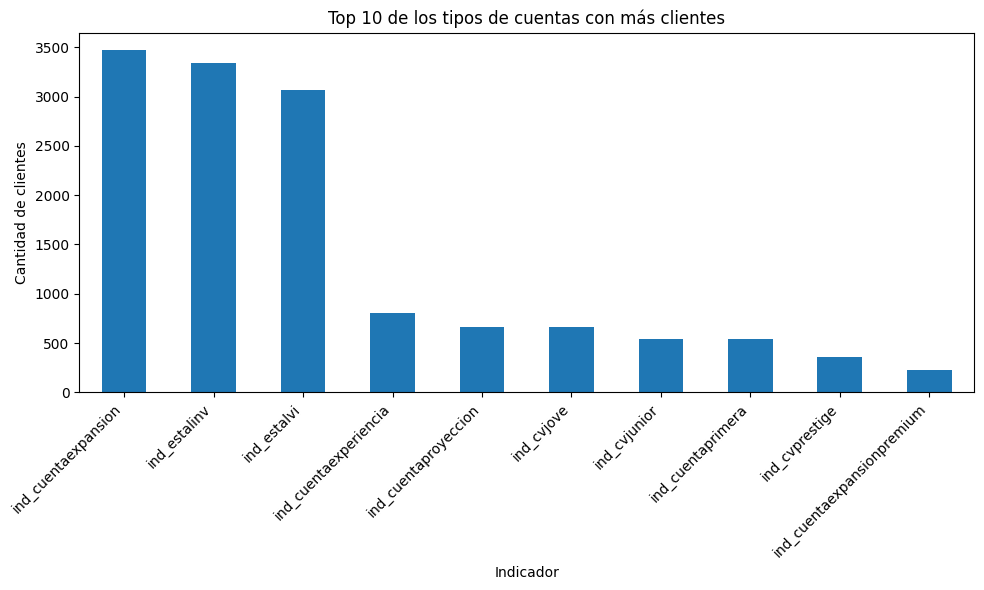

In [304]:
# Crear gráfico (funcionará ahora que conteo_indicadores está definido)
pd.Series(conteo_indicadores).sort_values(ascending=False).head(10).plot(
    kind='bar',
    title='Top 10 de los tipos de cuentas con más clientes',
    figsize=(10, 6)
)
plt.xlabel('Indicador')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Análisis: Relación entre Edad y Patrimonio Total
Tendencia Positiva Moderada: Se observa una correlación positiva clara entre la edad y el patrimonio total. A mayor edad, la nube de puntos se desplaza hacia valores más altos de patrimonio (especialmente visible entre los 20 y los 60 años), lo que refleja el proceso de acumulación de ahorro a lo largo de la vida laboral.

Pico en la Madurez (40–70 años): La mayor densidad de clientes y los patrimonios más elevados (alcanzando escalas de $10^5$ a $10^7$) se concentran en el rango de 40 a 70 años.

Caída en Edades Avanzadas (>80 años): A partir de los 80 años se aprecia una disminución gradual en el número de clientes y en el volumen total del patrimonio, coherente con la etapa de jubilación y consumo de ahorros/herencias.

Alta Dispersión y Sesgo: A pesar de la escala logarítmica en el eje $Y$, existe una dispersión masiva en todos los rangos de edad (desde valores por debajo de $10^{-1}$ hasta más de $10^5$), indicando que la edad por sí sola no determina completamente el nivel patrimonial, aunque sí marca su techo máximo.

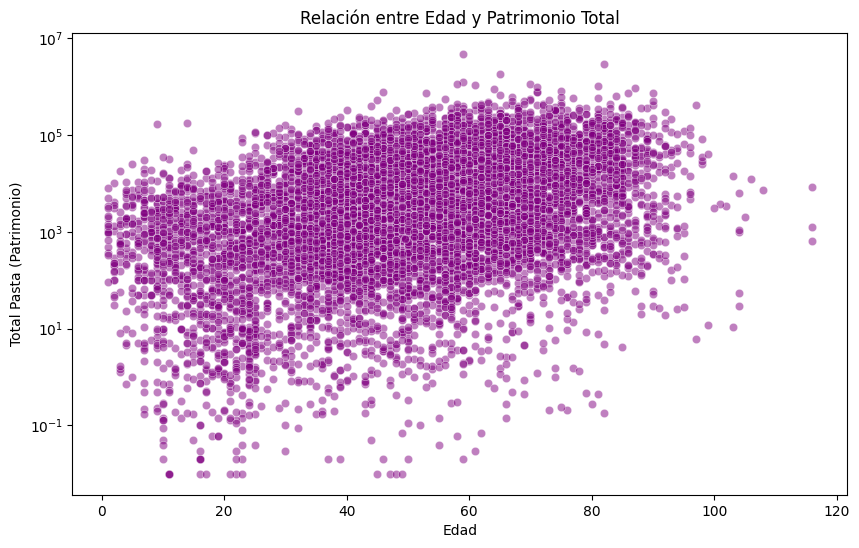

In [305]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='edad', y='totalpasta', data=df_datasabadell, alpha=0.5, color='purple')
plt.title('Relación entre Edad y Patrimonio Total')
plt.xlabel('Edad')
plt.ylabel('Total Pasta (Patrimonio)')
plt.yscale('log') # Opcional si hay valores muy altos concentrados
plt.show()

In [306]:
jovenes = df_datasabadell[df_datasabadell['segmento_edad'] == 'Joven (<=30)'].copy()
print(f'Clientes jóvenes en la muestra menos a 30 años: {len(jovenes)}')
print(jovenes['tiene_inversion'].value_counts(normalize=True).round(3))

Clientes jóvenes en la muestra menos a 30 años: 1790
tiene_inversion
0    0.797
1    0.203
Name: proportion, dtype: float64


El gráfico que se muestra acontinuación nos indica que los jóvenes no invierten en general, sino algo más accionable: la inversión en jóvenes está prácticamente ausente salvo por un único producto-puerta de entrada (ind_estalinv + partner), que arrastra consigo al 83% (304 de 364) de todos los jóvenes que sí invierten. 

In [307]:
# Definir data_j antes de usarlo
data_j = jovenes  # o jovenes.copy() si quieres una copia

fig = px.histogram(data_j, x='num_prod_inversion', color='tiene_inversion', nbins=25, barmode='overlay',
                    title='Distribución de productos de inversión en jóvenes',
                    labels={'num_prod_inversion':'Número de productos de inversión'})

fig.show()


In [308]:
# Crear carpeta BD_Actualizada si no existe
bd_actualizada_dir = Path.cwd() / "Output_BD_Actualizada"
bd_actualizada_dir.mkdir(exist_ok=True)

output_file =  f"datasabadell_actualizado.xlsx"

# Exportar el DataFrame actualizado
df_datasabadell.to_excel(output_file, index=False)
print(f"\nDataFrame exportado exitosamente: {output_file}")
print(f"Total de registros exportados: {len(df_datasabadell)}")



DataFrame exportado exitosamente: datasabadell_actualizado.xlsx
Total de registros exportados: 9936
